# 🧹 AI Canteen Cleanliness Inspector

## Phase 1 — Complaint Collection System

The application allows students to report cleanliness and hygiene issues in the university canteens.

Student-provided information:
- Canteen Number and Name
- Table Number
- Issue Category
- Description of the Problem

The system generates:
- Complaint ID
- Reported Time
- Complaint Status

The complaint is stored in the complaints database and saved for further processing.

### Phase 1 Workflow

Student
→ Select Canteen
→ Enter Table Number
→ Select Issue
→ Describe Problem
→ Submit Complaint
→ Store Complaint in Database

Importing Libraries

In [1]:
import pandas as pd
from datetime import datetime

Check Your Existing Tables

In [2]:
import pandas as pd

# Define column names for the dataframes
canteen_cols = ["Canteen No.", "Canteen Name"]
staff_cols = ["Staff ID", "Staff Name", "Role"]
complaints_cols = [
    "Complaint ID", "Canteen No.", "Canteen Name", "Table No.", "Issue",
    "Description", "Severity", "Priority", "Status", "Staff", "Reported Time"
]

# Initialize canteen_db with some sample data to allow the dropdown to work
canteen_data = {
    "Canteen No.": ["C01", "C02"],
    "Canteen Name": ["Central Canteen", "North Canteen"]
}
canteen_db = pd.DataFrame(canteen_data, columns=canteen_cols)

# Initialize staff_db as an empty DataFrame (add columns if specific ones are used later)
staff_db = pd.DataFrame(columns=staff_cols)

# Initialize complaints_db as an empty DataFrame with the expected columns
complaints_db = pd.DataFrame(columns=complaints_cols)

print("Canteen Table:")
display(canteen_db)

print("\nStaff Table:")
display(staff_db)

print("\nComplaint Table:")
display(complaints_db)

Canteen Table:


,Canteen No.,Canteen Name
0,C01,Central Canteen
1,C02,North Canteen



Staff Table:


,Staff ID,Staff Name,Role



Complaint Table:


,Complaint ID,Canteen No.,Canteen Name,Table No.,Issue,Description,Severity,Priority,Status,Staff,Reported Time


Create the Issue List

In [3]:
issue_categories = [
    "Dirty Table",
    "Spilled Food",
    "Leftover Plates",
    "Dirty Floor",
    "Bad Odour",
    "Pest",
    "Overflowing Trash",
    "Dirty Chairs",
    "Unclean Utensils",
    "Water Spill",
    "Food Waste",
    "Dirty Wash Area",
    "Blocked Bin Area",
    "Unclean Serving Area",
    "Other"
]

print(issue_categories)

['Dirty Table', 'Spilled Food', 'Leftover Plates', 'Dirty Floor', 'Bad Odour', 'Pest', 'Overflowing Trash', 'Dirty Chairs', 'Unclean Utensils', 'Water Spill', 'Food Waste', 'Dirty Wash Area', 'Blocked Bin Area', 'Unclean Serving Area', 'Other']


Create Canteen Dropdown Values

In [4]:
canteen_options = [
    f"{row['Canteen No.']} - {row['Canteen Name']}"
    for _, row in canteen_db.iterrows()
]

print(canteen_options)

['C01 - Central Canteen', 'C02 - North Canteen']


Create the Complaint Submission Function

In [5]:
def submit_complaint(canteen, table_number, issue, description):

    # Validate required fields
    if not canteen:
        return "❌ Please select a canteen.", complaints_db

    if not table_number:
        return "❌ Please enter a table number.", complaints_db

    if not issue:
        return "❌ Please select an issue.", complaints_db

    if not description or not description.strip():
        return "❌ Please provide a short description.", complaints_db

    # Generate Complaint ID
    if len(complaints_db) == 0:
        complaint_number = 1
    else:
        complaint_number = len(complaints_db) + 1

    complaint_id = f"C{complaint_number:03d}"

    # Current date and time
    current_time = datetime.now()

    # Extract canteen number and name
    canteen_no, canteen_name = canteen.split(" - ", 1)

    # Create new complaint
    new_complaint = {
        "Complaint ID": complaint_id,
        "Canteen No.": canteen_no,
        "Canteen Name": canteen_name,
        "Table No.": table_number,
        "Issue": issue,
        "Description": description,
        "Severity": "Not Classified",
        "Priority": "Not Classified",
        "Status": "Reported",
        "Staff": "Not Assigned",
        "Reported Time": current_time.strftime("%Y-%m-%d %H:%M:%S")
    }

    # Add complaint to DataFrame
    complaints_db.loc[len(complaints_db)] = new_complaint

    # Save updated database
    complaints_db.to_excel("Complaints_DB.xlsx", index=False)

    message = f"""
### ✅ Complaint Submitted Successfully

**Complaint ID:** {complaint_id}
**Canteen:** {canteen_name}
**Table:** {table_number}
**Issue:** {issue}
**Status:** Reported

Management will be notified.
"""

    return message, complaints_db

## Phase 2 — AI Complaint Intelligence

The Local LLM will analyse each complaint and generate:

- Issue Category
- Severity
- Priority
- Recommended Action
- Reason

Student-provided information:
- Canteen
- Table Number
- Issue
- Description

System-generated information:
- Complaint ID
- Reported Time
- Status
- Staff Assignment

Install Ollama

In [6]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [7]:
!apt-get update -qq
!apt-get install -y zstd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 111 not upgraded.


In [8]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


Start Ollama

In [9]:
import subprocess
import time

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("Ollama server started.")

Ollama server started.


In [10]:
!ollama list

NAME         ID              SIZE      MODIFIED    
gemma3:4b    a2af6cc3eb7f    3.3 GB    2 hours ago    


Download the Local LLM - Gemma 3 4B.

In [11]:
!ollama pull gemma3:4b

In [12]:
!ollama list

NAME         ID              SIZE      MODIFIED               
gemma3:4b    a2af6cc3eb7f    3.3 GB    Less than a second ago    


Test Gemma with a Complaint

In [13]:
import subprocess
import re

def analyze_complaint_with_ai(canteen, table_number, issue, description):

    prompt = f"""
You are the AI cleanliness inspector for a university canteen.

Analyze this complaint:

Canteen: {canteen}
Table Number: {table_number}
Reported Issue: {issue}
Description: {description}

Return EXACTLY these five lines.
Do not use JSON.
Do not use Markdown.
Do not add any other text.

Issue Category: [one short category]
Severity: [Low, Medium, High, or Critical]
Priority: [Routine, High, or Immediate]
Recommended Action: [one short action]
Reason: [one short reason]

Severity rules:
Low = minor cleanliness issue
Medium = noticeable issue requiring attention
High = significant hygiene or safety concern
Critical = immediate health or safety risk

Priority rules:
Routine = normal cleaning
High = should be handled soon
Immediate = requires immediate staff attention
"""

    result = subprocess.run(
        ["ollama", "run", "gemma3:4b", prompt],
        capture_output=True,
        text=True
    )

    response = result.stdout.strip()

    # Extract the five fields
    issue_category = re.search(
        r"Issue Category:\s*(.*)", response, re.IGNORECASE
    )

    severity = re.search(
        r"Severity:\s*(Low|Medium|High|Critical)",
        response,
        re.IGNORECASE
    )

    priority = re.search(
        r"Priority:\s*(Routine|High|Immediate)",
        response,
        re.IGNORECASE
    )

    recommended_action = re.search(
        r"Recommended Action:\s*(.*)",
        response,
        re.IGNORECASE
    )

    reason = re.search(
        r"Reason:\s*(.*)",
        response,
        re.IGNORECASE
    )

    return {
        "Issue Category": issue_category.group(1).strip() if issue_category else "Not Classified",
        "Severity": severity.group(1).title() if severity else "Not Classified",
        "Priority": priority.group(1).title() if priority else "Not Classified",
        "Recommended Action": recommended_action.group(1).strip() if recommended_action else "Not Available",
        "Reason": reason.group(1).strip() if reason else "Not Available"
    }

AI-Enabled Complaint Submission

In [14]:
def submit_complaint_with_ai(canteen, table_number, issue, description):

    # Validate required fields
    if not canteen:
        return "❌ Please select a canteen.", complaints_db

    if not table_number:
        return "❌ Please enter a table number.", complaints_db

    if not issue:
        return "❌ Please select an issue.", complaints_db

    if not description or not description.strip():
        return "❌ Please provide a short description.", complaints_db

    # Generate Complaint ID
    complaint_number = len(complaints_db) + 1
    complaint_id = f"C{complaint_number:03d}"

    # Current date and time
    current_time = datetime.now()

    # Extract canteen number and name
    canteen_no, canteen_name = canteen.split(" - ", 1)

    # Send complaint to Local LLM
    ai_result = analyze_complaint_with_ai(
        canteen,
        table_number,
        issue,
        description
    )

    # Create new complaint
    new_complaint = {
        "Complaint ID": complaint_id,
        "Canteen No.": canteen_no,
        "Canteen Name": canteen_name,
        "Table No.": table_number,
        "Issue": issue,
        "Description": description,
        "Severity": ai_result["Severity"],
        "Priority": ai_result["Priority"],
        "Status": "Reported",
        "Staff": "Not Assigned",
        "Reported Time": current_time.strftime("%Y-%m-%d %H:%M:%S")
    }

    # Add complaint to database
    complaints_db.loc[len(complaints_db)] = new_complaint

    # Save database
    complaints_db.to_excel("Complaints_DB.xlsx", index=False)

    message = f"""
### ✅ Complaint Submitted Successfully

**Complaint ID:** {complaint_id}
**Canteen:** {canteen_name}
**Table:** {table_number}
**Issue:** {issue}

### 🤖 AI Analysis

**Severity:** {ai_result["Severity"]}
**Priority:** {ai_result["Priority"]}

**Recommended Action:**
{ai_result["Recommended Action"]}

**Reason:**
{ai_result["Reason"]}

**Status:** Reported

Management will be notified.
"""

    return message, complaints_db

Verify AI Complaint Storage

In [15]:
print("Current Complaint Database:")
display(complaints_db)

print("\nChecking saved Excel file:")

saved_db = pd.read_excel("Complaints_DB.xlsx")
display(saved_db)

Current Complaint Database:


,Complaint ID,Canteen No.,Canteen Name,Table No.,Issue,Description,Severity,Priority,Status,Staff,Reported Time



Checking saved Excel file:


,Complaint ID,Canteen No.,Canteen Name,Table No.,Issue,Description,Severity,Priority,Status,Staff,Reported Time
0,C001,C01,Punjabi Bites,1,Spilled Food,There is spilled food on the floor near the ta...,Medium,High,Reported,Not Assigned,2026-09-01 18:24:45


Fix the issue_list error

In [16]:
# List of cleanliness issues
issue_list = [
    "Dirty Table",
    "Spilled Food",
    "Leftover Plates",
    "Dirty Floor",
    "Bad Odour",
    "Pest",
    "Overflowing Trash",
    "Empty Sanitizer",
    "No Gloves",
    "No Hairnet",
    "Dirty Utensils",
    "Unclean Drinking Water Area",
    "Blocked Sink",
    "Food Waste",
    "Other"
]

print("✅ Issue list loaded:", len(issue_list), "issues")

✅ Issue list loaded: 15 issues


# 📊 PHASE 3 — MANAGEMENT INTELLIGENCE & REPORTING

### Objective

Phase 3 focuses on transforming the complaint data collected by the AI Canteen Cleanliness Inspector into meaningful management insights.

The system will collect and analyze complaint records from multiple canteens and provide management with information about cleanliness issues, complaint frequency, severity, priority, canteen performance, and staff performance.

### Key Functions

* 📋 Analyze complaint records collected from the application
* 🏫 Compare cleanliness reports across different canteens
* 🧹 Identify the most frequently reported cleanliness issues
* ⚠️ Analyze complaint severity and priority
* 📅 Generate weekly and monthly complaint statistics
* 👥 Monitor staff workload and performance
* ⏱️ Analyze complaint status and resolution performance
* 📈 Identify trends and recurring cleanliness problems
* 🤖 Use the Local LLM to generate management summaries and recommendations

### Expected Outcome

The system will convert raw complaint data into structured management information and AI-generated reports that can help the canteen management identify recurring problems, prioritize urgent complaints, monitor cleanliness performance, and take appropriate corrective action.

Load the Complaint Database

In [17]:
import pandas as pd

# Load the latest complaint database
management_db = pd.read_excel("Complaints_DB.xlsx")

print("✅ Complaint database loaded successfully.")
print(f"Total complaints: {len(management_db)}")

display(management_db)

✅ Complaint database loaded successfully.
Total complaints: 1


,Complaint ID,Canteen No.,Canteen Name,Table No.,Issue,Description,Severity,Priority,Status,Staff,Reported Time
0,C001,C01,Punjabi Bites,1,Spilled Food,There is spilled food on the floor near the ta...,Medium,High,Reported,Not Assigned,2026-09-01 18:24:45


Generate Basic Complaint Statistics

In [18]:
print("📊 COMPLAINT STATISTICS")
print("=" * 40)

# Total complaints
total_complaints = len(management_db)

print(f"Total Complaints: {total_complaints}")

# Complaints by canteen
print("\n🏫 Complaints by Canteen:")
display(
    management_db["Canteen Name"]
    .value_counts()
    .rename_axis("Canteen")
    .reset_index(name="Complaints")
)

# Complaints by issue
print("\n🧹 Complaints by Issue:")
display(
    management_db["Issue"]
    .value_counts()
    .rename_axis("Issue")
    .reset_index(name="Complaints")
)

# Severity distribution
print("\n⚠️ Severity Distribution:")
display(
    management_db["Severity"]
    .value_counts()
    .rename_axis("Severity")
    .reset_index(name="Complaints")
)

# Priority distribution
print("\n🚨 Priority Distribution:")
display(
    management_db["Priority"]
    .value_counts()
    .rename_axis("Priority")
    .reset_index(name="Complaints")
)

# Status distribution
print("\n📌 Complaint Status:")
display(
    management_db["Status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Complaints")
)

📊 COMPLAINT STATISTICS
Total Complaints: 1

🏫 Complaints by Canteen:


,Canteen,Complaints
0,Punjabi Bites,1



🧹 Complaints by Issue:


,Issue,Complaints
0,Spilled Food,1



⚠️ Severity Distribution:


,Severity,Complaints
0,Medium,1



🚨 Priority Distribution:


,Priority,Complaints
0,High,1



📌 Complaint Status:


,Status,Complaints
0,Reported,1


Canteen-wise Performance

In [19]:
print("Management DB columns:")
print(management_db.columns.tolist())

print("\nComplaints DB columns:")
print(complaints_db.columns.tolist())

Management DB columns:
['Complaint ID', 'Canteen No.', 'Canteen Name', 'Table No.', 'Issue', 'Description', 'Severity', 'Priority', 'Status', 'Staff', 'Reported Time']

Complaints DB columns:
['Complaint ID', 'Canteen No.', 'Canteen Name', 'Table No.', 'Issue', 'Description', 'Severity', 'Priority', 'Status', 'Staff', 'Reported Time']


In [20]:
print("Complaints database:")
print("Rows:", len(complaints_db))
print("Columns:", complaints_db.columns.tolist())

print("\nManagement database:")
print("Rows:", len(management_db))
print("Columns:", management_db.columns.tolist())

display(complaints_db)

Complaints database:
Rows: 0
Columns: ['Complaint ID', 'Canteen No.', 'Canteen Name', 'Table No.', 'Issue', 'Description', 'Severity', 'Priority', 'Status', 'Staff', 'Reported Time']

Management database:
Rows: 1
Columns: ['Complaint ID', 'Canteen No.', 'Canteen Name', 'Table No.', 'Issue', 'Description', 'Severity', 'Priority', 'Status', 'Staff', 'Reported Time']


,Complaint ID,Canteen No.,Canteen Name,Table No.,Issue,Description,Severity,Priority,Status,Staff,Reported Time


In [21]:
print("🏫 CANTEEN-WISE PERFORMANCE")
print("=" * 45)

if management_db.empty:

    print("No complaints available for analysis.")
    print("Canteen-wise performance analysis will be generated")
    print("automatically when complaints are submitted.")

else:

    canteen_summary = (
        management_db
        .groupby("Canteen Name")
        .agg(
            Total_Complaints=("Complaint ID", "count"),
            High_Critical=("Severity",
                           lambda x: x.isin(["High", "Critical"]).sum()),
            Immediate_Priority=("Priority",
                                lambda x: (x == "Immediate").sum()),
            Reported_Complaints=("Status",
                                 lambda x: (x == "Reported").sum())
        )
        .reset_index()
    )

    most_common_issue = (
        management_db
        .groupby("Canteen Name")["Issue"]
        .agg(lambda x: x.value_counts().index[0])
        .reset_index()
        .rename(columns={"Issue": "Most_Common_Issue"})
    )

    canteen_summary = canteen_summary.merge(
        most_common_issue,
        on="Canteen Name",
        how="left"
    )

    display(canteen_summary)

🏫 CANTEEN-WISE PERFORMANCE


,Canteen Name,Total_Complaints,High_Critical,Immediate_Priority,Reported_Complaints,Most_Common_Issue
0,Punjabi Bites,1,0,0,1,Spilled Food


Issue & Cleanliness Analysis

In [22]:
print("🧹 CLEANLINESS ISSUE ANALYSIS")
print("=" * 45)

if management_db.empty:

    print("No complaints available for issue analysis.")
    print("Issue analysis will be generated automatically")
    print("when complaints are submitted.")

else:

    issue_summary = (
        management_db
        .groupby("Issue")
        .size()
        .reset_index(name="Total Complaints")
        .sort_values("Total Complaints", ascending=False)
    )

    display(issue_summary)

    most_reported_issue = issue_summary.iloc[0]

    print(
        f"\n🔴 Most Reported Issue: "
        f"{most_reported_issue['Issue']} "
        f"({most_reported_issue['Total Complaints']} complaint(s))"
    )


🧹 CLEANLINESS ISSUE ANALYSIS


,Issue,Total Complaints
0,Spilled Food,1



🔴 Most Reported Issue: Spilled Food (1 complaint(s))


Time-Based Complaint Analysis

In [23]:
print("📅 TIME-BASED COMPLAINT ANALYSIS")
print("=" * 45)

if management_db.empty:

    print("No complaints available for time-based analysis.")
    print("Time-based analysis will be generated automatically")
    print("when complaints are submitted.")

else:

    # Convert Reported Time to datetime
    management_db["Reported Time"] = pd.to_datetime(
        management_db["Reported Time"],
        errors="coerce"
    )

    # Complaints by date
    complaints_by_date = (
        management_db
        .dropna(subset=["Reported Time"])
        .groupby(management_db["Reported Time"].dt.date)
        .size()
        .reset_index(name="Complaints")
    )

    print("\n📌 Complaints by Date:")
    display(complaints_by_date)

    # Complaints by day of week
    complaints_by_day = (
        management_db
        .dropna(subset=["Reported Time"])
        .groupby(management_db["Reported Time"].dt.day_name())
        .size()
        .reset_index(name="Complaints")
    )

    print("\n📆 Complaints by Day of Week:")
    display(complaints_by_day)

    # Complaints by hour
    complaints_by_hour = (
        management_db
        .dropna(subset=["Reported Time"])
        .groupby(management_db["Reported Time"].dt.hour)
        .size()
        .reset_index(name="Complaints")
        .sort_values("Reported Time")
    )

    print("\n🕐 Complaints by Hour:")
    display(complaints_by_hour)

📅 TIME-BASED COMPLAINT ANALYSIS

📌 Complaints by Date:


,Reported Time,Complaints
0,2026-09-01,1



📆 Complaints by Day of Week:


,Reported Time,Complaints
0,Tuesday,1



🕐 Complaints by Hour:


,Reported Time,Complaints
0,18,1


Complaint Resolution Analysis

In [24]:
print("📌 RESOLUTION ANALYSIS")
print("=" * 45)

if management_db.empty:

    print("No complaints available for resolution analysis.")
    print("Resolution analysis will be generated automatically")
    print("when complaints are submitted.")

else:

    resolution_summary = (
        management_db
        .groupby("Status")
        .size()
        .reset_index(name="Complaints")
        .sort_values("Complaints", ascending=False)
    )

    print("\n📊 Complaint Status Distribution:")
    display(resolution_summary)

    total_complaints = len(management_db)

    resolved_count = (
        management_db["Status"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["resolved", "closed"])
        .sum()
    )

    pending_count = total_complaints - resolved_count

    resolution_rate = (
        (resolved_count / total_complaints) * 100
        if total_complaints > 0 else 0
    )

    print(f"\nTotal Complaints: {total_complaints}")
    print(f"Resolved/Closed: {resolved_count}")
    print(f"Pending: {pending_count}")
    print(f"Resolution Rate: {resolution_rate:.2f}%")

📌 RESOLUTION ANALYSIS

📊 Complaint Status Distribution:


,Status,Complaints
0,Reported,1



Total Complaints: 1
Resolved/Closed: 0
Pending: 1
Resolution Rate: 0.00%


Staff Performance Analysis

In [25]:
print("👨‍💼 STAFF PERFORMANCE ANALYSIS")
print("=" * 45)

if management_db.empty:

    print("No complaints available for staff performance analysis.")
    print("Staff performance analysis will be generated automatically")
    print("when complaints are assigned to staff.")

else:

    # Only analyse complaints where staff has been assigned
    assigned_complaints = management_db[
        management_db["Staff"].notna() &
        (management_db["Staff"].astype(str).str.strip() != "") &
        (management_db["Staff"].astype(str).str.lower() != "not assigned")
    ].copy()

    if assigned_complaints.empty:

        print("No complaints have been assigned to staff yet.")
        print("Staff performance analysis will be generated")
        print("when complaints are assigned.")

    else:

        staff_summary = (
            assigned_complaints
            .groupby("Staff")
            .agg(
                Total_Complaints=("Complaint ID", "count"),
                Resolved_Complaints=(
                    "Status",
                    lambda x: x.astype(str).str.strip().str.lower()
                    .isin(["resolved", "closed"]).sum()
                ),
                Pending_Complaints=(
                    "Status",
                    lambda x: ~x.astype(str).str.strip().str.lower()
                    .isin(["resolved", "closed"]).sum()
                )
            )
            .reset_index()
        )

        staff_summary["Resolution_Rate_%"] = (
            staff_summary["Resolved_Complaints"]
            / staff_summary["Total_Complaints"]
            * 100
        ).round(2)

        display(staff_summary)

👨‍💼 STAFF PERFORMANCE ANALYSIS
No complaints have been assigned to staff yet.
Staff performance analysis will be generated
when complaints are assigned.


Management Dashboard Metrics

In [26]:
print("📊 MANAGEMENT DASHBOARD — KEY METRICS")
print("=" * 50)

if management_db.empty:

    print("No complaints available for dashboard metrics.")
    print("Dashboard KPIs will be generated automatically")
    print("when complaints are submitted.")

else:

    total_complaints = len(management_db)

    high_critical = management_db["Severity"].isin(
        ["High", "Critical"]
    ).sum()

    immediate_priority = (
        management_db["Priority"] == "Immediate"
    ).sum()

    reported_complaints = (
        management_db["Status"] == "Reported"
    ).sum()

    resolved_complaints = (
        management_db["Status"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["resolved", "closed"])
        .sum()
    )

    resolution_rate = (
        resolved_complaints / total_complaints * 100
        if total_complaints > 0 else 0
    )

    print(f"Total Complaints       : {total_complaints}")
    print(f"High/Critical Issues   : {high_critical}")
    print(f"Immediate Priority     : {immediate_priority}")
    print(f"Reported Complaints    : {reported_complaints}")
    print(f"Resolved/Closed       : {resolved_complaints}")
    print(f"Resolution Rate       : {resolution_rate:.2f}%")

📊 MANAGEMENT DASHBOARD — KEY METRICS
Total Complaints       : 1
High/Critical Issues   : 0
Immediate Priority     : 0
Reported Complaints    : 1
Resolved/Closed       : 0
Resolution Rate       : 0.00%


Management Dashboard Charts

📊 MANAGEMENT DASHBOARD CHARTS


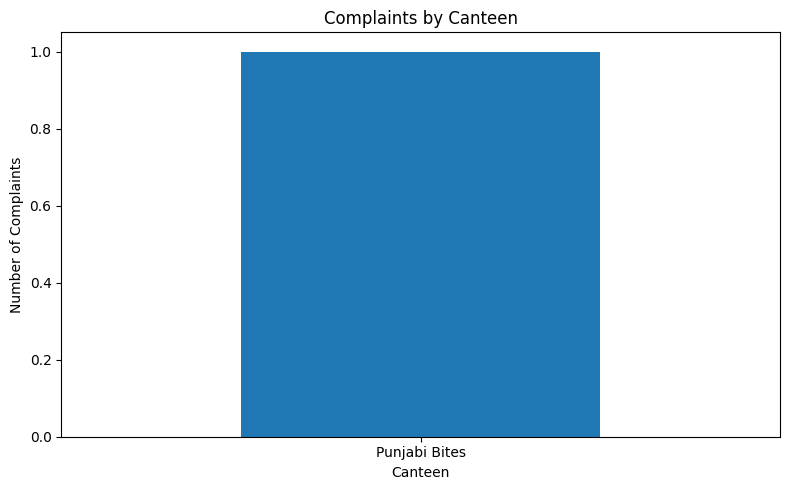

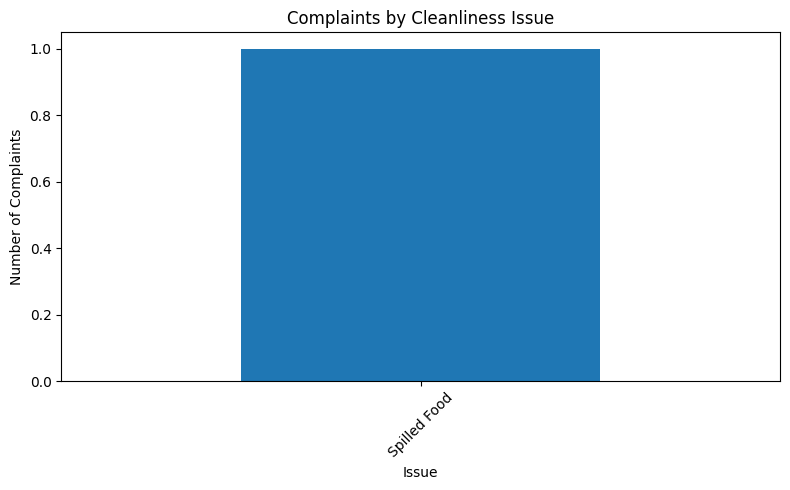

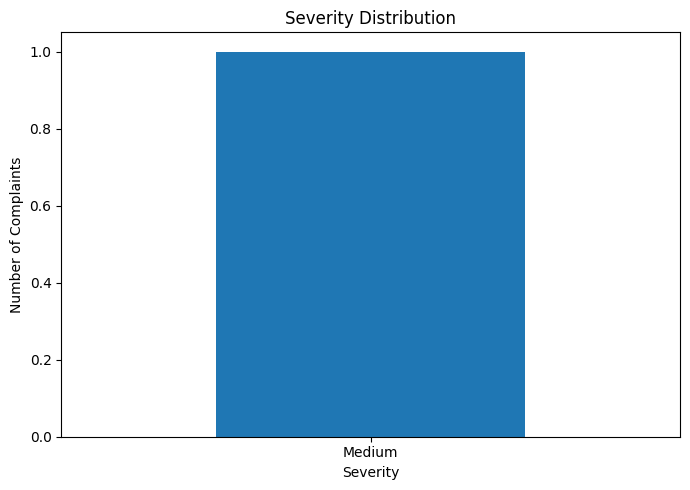

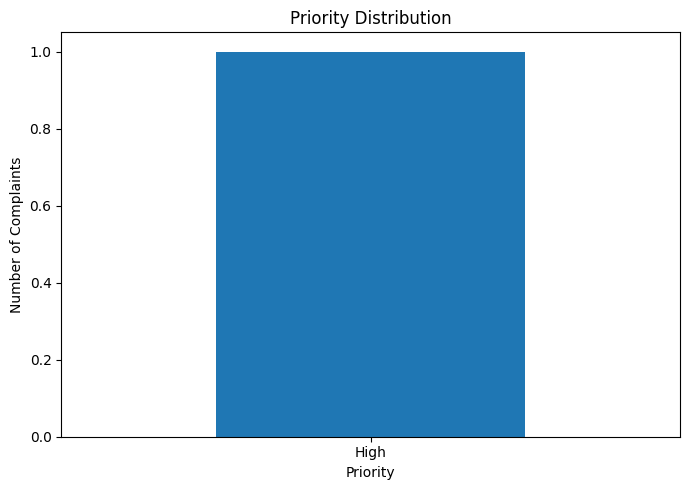

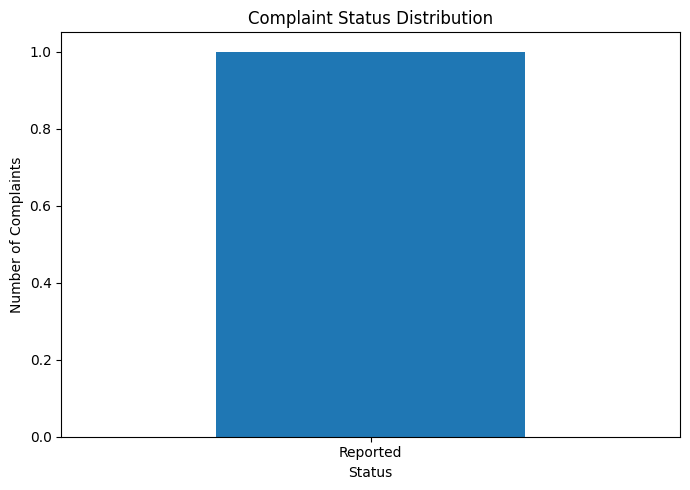

In [27]:
import matplotlib.pyplot as plt

print("📊 MANAGEMENT DASHBOARD CHARTS")
print("=" * 45)

if management_db.empty:

    print("No complaints available for visualization.")
    print("Charts will be generated automatically")
    print("when complaints are submitted.")

else:

    # 1. Complaints by Canteen
    canteen_counts = management_db["Canteen Name"].value_counts()

    plt.figure(figsize=(8, 5))
    canteen_counts.plot(kind="bar")
    plt.title("Complaints by Canteen")
    plt.xlabel("Canteen")
    plt.ylabel("Number of Complaints")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


    # 2. Complaints by Issue
    issue_counts = management_db["Issue"].value_counts()

    plt.figure(figsize=(8, 5))
    issue_counts.plot(kind="bar")
    plt.title("Complaints by Cleanliness Issue")
    plt.xlabel("Issue")
    plt.ylabel("Number of Complaints")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    # 3. Severity Distribution
    severity_counts = management_db["Severity"].value_counts()

    plt.figure(figsize=(7, 5))
    severity_counts.plot(kind="bar")
    plt.title("Severity Distribution")
    plt.xlabel("Severity")
    plt.ylabel("Number of Complaints")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


    # 4. Priority Distribution
    priority_counts = management_db["Priority"].value_counts()

    plt.figure(figsize=(7, 5))
    priority_counts.plot(kind="bar")
    plt.title("Priority Distribution")
    plt.xlabel("Priority")
    plt.ylabel("Number of Complaints")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


    # 5. Complaint Status
    status_counts = management_db["Status"].value_counts()

    plt.figure(figsize=(7, 5))
    status_counts.plot(kind="bar")
    plt.title("Complaint Status Distribution")
    plt.xlabel("Status")
    plt.ylabel("Number of Complaints")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Weekly AI Management Report

In [28]:
from datetime import datetime, timedelta

print("📅 WEEKLY MANAGEMENT DATA")
print("=" * 45)

if management_db.empty:

    print("No complaints available for weekly analysis.")
    print("Weekly management data will be generated")
    print("automatically when complaints are submitted.")

else:

    # Make sure Reported Time is datetime
    management_db["Reported Time"] = pd.to_datetime(
        management_db["Reported Time"],
        errors="coerce"
    )

    # Remove rows where date is unavailable
    valid_data = management_db.dropna(
        subset=["Reported Time"]
    ).copy()

    if valid_data.empty:

        print("No valid complaint dates available for weekly analysis.")

    else:

        # Latest complaint date
        latest_date = valid_data["Reported Time"].max()

        # Start of the 7-day reporting period
        week_start = latest_date - timedelta(days=6)

        # Filter complaints from the last 7 days
        weekly_data = valid_data[
            (valid_data["Reported Time"] >= week_start) &
            (valid_data["Reported Time"] <= latest_date)
        ].copy()

        print(
            f"Reporting Period: "
            f"{week_start.strftime('%Y-%m-%d')} "
            f"to {latest_date.strftime('%Y-%m-%d')}"
        )

        print(f"Total Weekly Complaints: {len(weekly_data)}")

        print("\nComplaints by Canteen:")
        display(
            weekly_data["Canteen Name"]
            .value_counts()
            .rename_axis("Canteen")
            .reset_index(name="Complaints")
        )

        print("\nComplaints by Issue:")
        display(
            weekly_data["Issue"]
            .value_counts()
            .rename_axis("Issue")
            .reset_index(name="Complaints")
        )

        print("\nSeverity:")
        display(
            weekly_data["Severity"]
            .value_counts()
            .rename_axis("Severity")
            .reset_index(name="Complaints")
        )

        print("\nPriority:")
        display(
            weekly_data["Priority"]
            .value_counts()
            .rename_axis("Priority")
            .reset_index(name="Complaints")
        )

        print("\nStatus:")
        display(
            weekly_data["Status"]
            .value_counts()
            .rename_axis("Status")
            .reset_index(name="Complaints")
        )

📅 WEEKLY MANAGEMENT DATA
Reporting Period: 2026-08-26 to 2026-09-01
Total Weekly Complaints: 1

Complaints by Canteen:


,Canteen,Complaints
0,Punjabi Bites,1



Complaints by Issue:


,Issue,Complaints
0,Spilled Food,1



Severity:


,Severity,Complaints
0,Medium,1



Priority:


,Priority,Complaints
0,High,1



Status:


,Status,Complaints
0,Reported,1


Generate Weekly AI Management Report

In [29]:
import subprocess

print("🤖 WEEKLY AI MANAGEMENT REPORT")
print("=" * 60)

if management_db.empty:

    print("No complaints available for the weekly AI report.")
    print("The AI management report will be generated")
    print("automatically when complaints are submitted.")

elif "weekly_data" not in globals() or weekly_data.empty:

    print("No complaints available for the selected week.")
    print("The AI management report cannot be generated yet.")

else:

    def generate_weekly_ai_report(weekly_data, week_start, latest_date):

        summary = f"""
Generate a concise weekly management report for a university canteen
cleanliness monitoring system.

Reporting Period:
{week_start.strftime('%Y-%m-%d')} to {latest_date.strftime('%Y-%m-%d')}

Total Complaints: {len(weekly_data)}

Complaints by Canteen:
{weekly_data["Canteen Name"].value_counts().to_dict()}

Complaints by Issue:
{weekly_data["Issue"].value_counts().to_dict()}

Severity Distribution:
{weekly_data["Severity"].value_counts().to_dict()}

Priority Distribution:
{weekly_data["Priority"].value_counts().to_dict()}

Status Distribution:
{weekly_data["Status"].value_counts().to_dict()}

Prepare the report with:
1. Weekly Overview
2. Canteen Performance
3. Major Cleanliness Issues
4. Risk and Priority Assessment
5. Management Recommendations
6. Conclusion

Keep the report professional and concise.
Do not invent information that is not present in the data.
"""

        result = subprocess.run(
            ["ollama", "run", "gemma3:4b", summary],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            return "AI report generation failed: " + result.stderr

        return result.stdout.strip()

    weekly_ai_report = generate_weekly_ai_report(
        weekly_data,
        week_start,
        latest_date
    )

    print(weekly_ai_report)

🤖 WEEKLY AI MANAGEMENT REPORT
## University Canteen - Weekly Management Report
**Reporting Period:** 2026-08-26 to 2026-09-01

**1. Weekly Overview:**

This report summarizes the cleanliness monitoring activities and associated
associated issues for the university canteen during the week of August 26th
26th to September 1st, 2026.  Overall operational performance remains withi
within acceptable parameters, however, one complaint was received requiring
requiring immediate attention.

**2. Canteen Performance:**

*   **Total Complaints:** 1
*   **Canteen with Complaints:** Punjabi Bites
*   **Complaint Type:** Spilled Food

**3. Major Cleanliness Issues:**

*   One complaint was received regarding spilled food at the Punjabi Bites 
canteen. 

**4. Risk and Priority Assessment:**

| Metric            | Value | Priority | Severity |
|--------------------|-------|----------|----------|
| Reported Complaints | 1     | High      | Medium    |

**5. Management Recommendations:**

*   **Punjabi

Monthly Canteen Cleanliness Management Report

In [30]:
print("📅 MONTHLY MANAGEMENT DATA")
print("=" * 45)

if management_db.empty:

    print("No complaints available for monthly analysis.")
    print("Monthly management data will be generated")
    print("automatically when complaints are submitted.")

else:

    # Make sure Reported Time is datetime
    management_db["Reported Time"] = pd.to_datetime(
        management_db["Reported Time"],
        errors="coerce"
    )

    valid_data = management_db.dropna(
        subset=["Reported Time"]
    ).copy()

    if valid_data.empty:

        print("No valid complaint dates available for monthly analysis.")

    else:

        # Latest complaint date
        latest_date = valid_data["Reported Time"].max()

        # First day of the month
        month_start = latest_date.replace(
            day=1,
            hour=0,
            minute=0,
            second=0
        )

        # Filter complaints for the month
        monthly_data = valid_data[
            (valid_data["Reported Time"] >= month_start) &
            (valid_data["Reported Time"] <= latest_date)
        ].copy()

        print(
            f"Reporting Period: "
            f"{month_start.strftime('%Y-%m-%d')} "
            f"to {latest_date.strftime('%Y-%m-%d')}"
        )

        print(f"Total Monthly Complaints: {len(monthly_data)}")

        print("\nComplaints by Canteen:")
        display(
            monthly_data["Canteen Name"]
            .value_counts()
            .rename_axis("Canteen")
            .reset_index(name="Complaints")
        )

        print("\nComplaints by Issue:")
        display(
            monthly_data["Issue"]
            .value_counts()
            .rename_axis("Issue")
            .reset_index(name="Complaints")
        )

        print("\nSeverity:")
        display(
            monthly_data["Severity"]
            .value_counts()
            .rename_axis("Severity")
            .reset_index(name="Complaints")
        )

        print("\nPriority:")
        display(
            monthly_data["Priority"]
            .value_counts()
            .rename_axis("Priority")
            .reset_index(name="Complaints")
        )

        print("\nStatus:")
        display(
            monthly_data["Status"]
            .value_counts()
            .rename_axis("Status")
            .reset_index(name="Complaints")
        )

📅 MONTHLY MANAGEMENT DATA
Reporting Period: 2026-09-01 to 2026-09-01
Total Monthly Complaints: 1

Complaints by Canteen:


,Canteen,Complaints
0,Punjabi Bites,1



Complaints by Issue:


,Issue,Complaints
0,Spilled Food,1



Severity:


,Severity,Complaints
0,Medium,1



Priority:


,Priority,Complaints
0,High,1



Status:


,Status,Complaints
0,Reported,1


Monthly AI Management Report

In [31]:
import subprocess

print("🤖 MONTHLY AI MANAGEMENT REPORT")
print("=" * 60)

if management_db.empty:

    print("No complaints available for the monthly AI report.")
    print("The AI management report will be generated")
    print("automatically when complaints are submitted.")

elif "monthly_data" not in globals() or monthly_data.empty:

    print("No complaints available for the selected month.")
    print("The monthly AI report cannot be generated yet.")

else:

    def generate_monthly_ai_report(
        monthly_data,
        month_start,
        latest_date
    ):

        summary = f"""
Generate a concise monthly management report for a
university canteen cleanliness monitoring system.

Reporting Period:
{month_start.strftime('%Y-%m-%d')} to {latest_date.strftime('%Y-%m-%d')}

Total Monthly Complaints: {len(monthly_data)}

Complaints by Canteen:
{monthly_data["Canteen Name"].value_counts().to_dict()}

Complaints by Issue:
{monthly_data["Issue"].value_counts().to_dict()}

Severity Distribution:
{monthly_data["Severity"].value_counts().to_dict()}

Priority Distribution:
{monthly_data["Priority"].value_counts().to_dict()}

Status Distribution:
{monthly_data["Status"].value_counts().to_dict()}

Prepare the report with:

1. Monthly Overview
2. Canteen Performance
3. Major Cleanliness Issues
4. Risk and Priority Assessment
5. Management Recommendations
6. Conclusion

Keep the report professional and concise.
Do not invent information that is not present in the data.
"""

        result = subprocess.run(
            ["ollama", "run", "gemma3:4b", summary],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            return "AI report generation failed: " + result.stderr

        return result.stdout.strip()

    monthly_ai_report = generate_monthly_ai_report(
        monthly_data,
        month_start,
        latest_date
    )

    print(monthly_ai_report)

🤖 MONTHLY AI MANAGEMENT REPORT
## University Canteen Cleanliness Monitoring System - Monthly Report
**Reporting Period: 2026-09-01 to 2026-09-01**

**1. Monthly Overview:**

This report summarizes the cleanliness monitoring data for the university c
canteen system for the period of September 1st, 2026. A total of one (1) co
complaint was received during the month.

**2. Canteen Performance:**

*   **Punjabi Bites:**  Received all one (1) complaint reported during the 
month.

**3. Major Cleanliness Issues:**

The single complaint received related to ‘Spilled Food’.

**4. Risk and Priority Assessment:**

| Distribution        | Value | Priority |
|---------------------|-------|----------|
| Severity            | 1     | High     |
| Priority            | 1     | High     |
| Status              | 1     | Reported |

**5. Management Recommendations:**

*   **Immediate Investigation:** Conduct a thorough investigation into the 
cause of the spilled food complaint at Punjabi Bites.
*   **S

# 🚀 PHASE 4 — STREAMLIT FINAL APPLICATION

This phase converts the developed AI Canteen Cleanliness Inspector into an interactive web application using Streamlit.

The application provides two main interfaces:

1. **Student Interface**
   - Select canteen
   - Enter table number
   - Select cleanliness issue
   - Provide complaint description
   - Submit complaint
   - Receive complaint ID and AI-based severity and priority

2. **Management Interface**
   - View complaint statistics
   - Monitor canteen-wise complaints
   - Analyse cleanliness issues
   - Monitor complaint status
   - Review staff performance
   - Generate weekly and monthly AI reports

The Streamlit application acts as the final user-facing layer while the previously developed Python analytics, complaint database, and local Gemma 3:4B model provide the backend intelligence.

In [32]:
!pip install -q streamlit

In [33]:
%%writefile app.py

import streamlit as st
import pandas as pd
import subprocess
import json
import re
import os
from datetime import datetime


st.set_page_config(
    page_title="AI Canteen Cleanliness Inspector",
    page_icon="🧹",
    layout="wide",
    initial_sidebar_state="expanded"
)


st.markdown("""
<style>

.block-container {
    padding-top: 2rem;
    padding-bottom: 3rem;
    max-width: 1200px;
}

.main-title {
    font-size: 40px;
    font-weight: 700;
    text-align: center;
    margin-bottom: 5px;
}

.main-subtitle {
    text-align: center;
    font-size: 17px;
    margin-bottom: 30px;
    opacity: 0.75;
}

[data-testid="stForm"] {
    padding: 25px;
    border-radius: 15px;
    border: 1px solid rgba(128,128,128,0.35);
    background-color: rgba(255,255,255,0.04);
}

[data-testid="stMetric"] {
    border: 1px solid rgba(128,128,128,0.35);
    border-radius: 12px;
    padding: 15px;
}

.stButton > button,
.stFormSubmitButton > button {
    border-radius: 8px;
    font-weight: 600;
    min-height: 45px;
}

[data-testid="stSidebar"] {
    border-right: 1px solid rgba(128,128,128,0.25);
}

</style>
""", unsafe_allow_html=True)


CANTEEN_FILE = "Canteen_DB.xlsx"
COMPLAINT_FILE = "Complaints_DB.xlsx"


def load_canteens():

    if os.path.exists(CANTEEN_FILE):

        df = pd.read_excel(CANTEEN_FILE)

        required_columns = [
            "Canteen No.",
            "Canteen Name"
        ]

        for col in required_columns:
            if col not in df.columns:
                df[col] = ""

        return df[required_columns]

    return pd.DataFrame({
        "Canteen No.": ["C01"],
        "Canteen Name": ["Central Canteen"]
    })


def load_complaints():

    columns = [
        "Complaint ID",
        "Canteen No.",
        "Canteen Name",
        "Table No.",
        "Issue",
        "Description",
        "Severity",
        "Priority",
        "Status",
        "Staff",
        "Reported Time"
    ]

    if os.path.exists(COMPLAINT_FILE):

        df = pd.read_excel(COMPLAINT_FILE)

        for col in columns:

            if col not in df.columns:
                df[col] = ""

        return df[columns]

    return pd.DataFrame(columns=columns)


canteen_db = load_canteens()
complaints_db = load_complaints()


issue_categories = [
    "Dirty Table",
    "Spilled Food",
    "Leftover Plates",
    "Dirty Floor",
    "Bad Odour",
    "Pest",
    "Overflowing Trash",
    "Dirty Chairs",
    "Unclean Utensils",
    "Water Spill",
    "Food Waste",
    "Dirty Wash Area",
    "Blocked Bin Area",
    "Unclean Serving Area",
    "Other"
]


def analyze_complaint(issue, description):

    prompt = f"""
You are an AI cleanliness complaint analysis system
for a university canteen.

Analyze the following complaint.

Issue: {issue}

Description: {description}

Return ONLY a JSON object with exactly these fields:

{{
    "issue_category": "...",
    "severity": "...",
    "priority": "...",
    "recommended_action": "...",
    "reason": "..."
}}

Allowed Severity:
Low, Medium, High, Critical

Allowed Priority:
Routine, High, Immediate

Do not use markdown.
Do not use code fences.
Do not add explanations outside the JSON.
"""

    try:

        result = subprocess.run(
            ["ollama", "run", "gemma3:4b", prompt],
            capture_output=True,
            text=True,
            timeout=120
        )

        raw_response = result.stdout.strip()

        raw_response = re.sub(
            r"```json|```",
            "",
            raw_response,
            flags=re.IGNORECASE
        ).strip()

        match = re.search(
            r"\{.*\}",
            raw_response,
            re.DOTALL
        )

        if match:

            data = json.loads(match.group(0))

            severity = data.get(
                "severity",
                "Medium"
            )

            priority = data.get(
                "priority",
                "High"
            )

            if severity not in [
                "Low",
                "Medium",
                "High",
                "Critical"
            ]:
                severity = "Medium"

            if priority not in [
                "Routine",
                "High",
                "Immediate"
            ]:
                priority = "High"

            return {
                "issue_category": data.get(
                    "issue_category",
                    issue
                ),
                "severity": severity,
                "priority": priority,
                "recommended_action": data.get(
                    "recommended_action",
                    "Inspect and clean the affected area"
                ),
                "reason": data.get(
                    "reason",
                    "The reported cleanliness issue requires attention."
                )
            }

    except Exception:
        pass

    return {
        "issue_category": issue,
        "severity": "Medium",
        "priority": "High",
        "recommended_action": "Inspect and clean the affected area",
        "reason": "The reported cleanliness issue requires attention."
    }


st.markdown(
    '<div class="main-title">'
    '🧹 AI Canteen Cleanliness Inspector'
    '</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="main-subtitle">'
    'Smart complaint reporting and AI-powered hygiene monitoring system'
    '</div>',
    unsafe_allow_html=True
)


st.sidebar.title("🧹 Canteen Inspector")

st.sidebar.markdown("---")

page = st.sidebar.radio(
    "Navigation",
    [
        "👨‍🎓 Student Complaint",
        "👨‍💼 Management Dashboard"
    ]
)

st.sidebar.markdown("---")

st.sidebar.caption(
    "AI-powered cleanliness monitoring system"
)


if page == "👨‍🎓 Student Complaint":

    st.subheader("📝 Report a Cleanliness Issue")

    st.write(
        "Help us maintain a clean and hygienic canteen "
        "by reporting any cleanliness issue you observe."
    )

    st.markdown("### Complaint Details")

    with st.form("complaint_form"):

        canteen_options = [
            f"{row['Canteen No.']} - {row['Canteen Name']}"
            for _, row in canteen_db.iterrows()
        ]

        if len(canteen_options) == 0:

            canteen_options = [
                "C01 - Central Canteen"
            ]

        col1, col2 = st.columns(2)

        with col1:

            canteen = st.selectbox(
                "🏫 Canteen",
                canteen_options
            )

        with col2:

            table_number = st.number_input(
                "🪑 Table Number",
                min_value=1,
                step=1
            )

        issue = st.selectbox(
            "🧹 Type of Issue",
            issue_categories
        )

        description = st.text_area(
            "📋 Describe the Problem",
            placeholder=(
                "Example: There is spilled food on the "
                "floor near the table."
            ),
            height=130
        )

        st.markdown("")

        submitted = st.form_submit_button(
            "🚨 Submit Complaint",
            use_container_width=True
        )


    if submitted:

        if not description.strip():

            st.error(
                "⚠️ Please describe the cleanliness issue "
                "before submitting."
            )

        else:

            if len(complaints_db) == 0:

                complaint_number = 1

            else:

                existing_ids = (
                    complaints_db["Complaint ID"]
                    .astype(str)
                    .str.extract(r"(\d+)")
                    .dropna()
                )

                if len(existing_ids) > 0:

                    complaint_number = (
                        existing_ids[0]
                        .astype(int)
                        .max()
                        + 1
                    )

                else:

                    complaint_number = 1


            complaint_id = f"C{complaint_number:03d}"


            canteen_no, canteen_name = canteen.split(
                " - ",
                1
            )


            with st.spinner(
                "🤖 AI is analysing your complaint..."
            ):

                ai_result = analyze_complaint(
                    issue,
                    description
                )


            new_complaint = {

                "Complaint ID": complaint_id,

                "Canteen No.": canteen_no,

                "Canteen Name": canteen_name,

                "Table No.": table_number,

                "Issue": issue,

                "Description": description,

                "Severity": ai_result["severity"],

                "Priority": ai_result["priority"],

                "Status": "Reported",

                "Staff": "Not Assigned",

                "Reported Time":
                    datetime.now().strftime(
                        "%Y-%m-%d %H:%M:%S"
                    )
            }


            complaints_db = pd.concat(
                [
                    complaints_db,
                    pd.DataFrame([new_complaint])
                ],
                ignore_index=True
            )


            complaints_db.to_excel(
                COMPLAINT_FILE,
                index=False
            )


            st.success(
                f"✅ Complaint {complaint_id} "
                f"submitted successfully!"
            )


            st.markdown("### 🤖 AI Analysis")


            col1, col2 = st.columns(2)

            with col1:

                st.metric(
                    "⚠️ Severity",
                    ai_result["severity"]
                )

            with col2:

                st.metric(
                    "🚨 Priority",
                    ai_result["priority"]
                )


            st.write(
                "**Issue Category:**",
                ai_result["issue_category"]
            )

            st.write(
                "**Recommended Action:**",
                ai_result["recommended_action"]
            )

            st.write(
                "**Reason:**",
                ai_result["reason"]
            )

            st.info(
                f"📌 Complaint ID: **{complaint_id}**  |  "
                f"Status: **Reported**"
            )


else:

    st.subheader("👨‍💼 Management Dashboard")

    st.write(
        "Monitor cleanliness complaints, risks and complaint trends."
    )


    if complaints_db.empty:

        st.info(
            "📊 No complaints have been submitted yet. "
            "Dashboard statistics will appear automatically "
            "after complaints are reported."
        )

    else:

        complaints_db["Reported Time"] = pd.to_datetime(
            complaints_db["Reported Time"],
            errors="coerce"
        )


        total = len(complaints_db)


        high_critical = complaints_db[
            complaints_db["Severity"].isin(
                ["High", "Critical"]
            )
        ].shape[0]


        immediate = complaints_db[
            complaints_db["Priority"] == "Immediate"
        ].shape[0]


        reported = complaints_db[
            complaints_db["Status"] == "Reported"
        ].shape[0]


        resolved = complaints_db[
            complaints_db["Status"]
            .astype(str)
            .str.lower()
            .isin(
                ["resolved", "closed"]
            )
        ].shape[0]


        col1, col2, col3, col4, col5 = st.columns(5)


        col1.metric(
            "Total",
            total
        )

        col2.metric(
            "High/Critical",
            high_critical
        )

        col3.metric(
            "Immediate",
            immediate
        )

        col4.metric(
            "Reported",
            reported
        )

        col5.metric(
            "Resolved",
            resolved
        )


        st.divider()


        col1, col2 = st.columns(2)


        with col1:

            st.subheader(
                "🏫 Complaints by Canteen"
            )

            st.bar_chart(
                complaints_db[
                    "Canteen Name"
                ].value_counts()
            )


        with col2:

            st.subheader(
                "🧹 Complaints by Issue"
            )

            st.bar_chart(
                complaints_db[
                    "Issue"
                ].value_counts()
            )


        col1, col2 = st.columns(2)


        with col1:

            st.subheader(
                "⚠️ Severity Distribution"
            )

            st.bar_chart(
                complaints_db[
                    "Severity"
                ].value_counts()
            )


        with col2:

            st.subheader(
                "🚨 Priority Distribution"
            )

            st.bar_chart(
                complaints_db[
                    "Priority"
                ].value_counts()
            )


        st.subheader(
            "📋 Complaint Records"
        )


        display_columns = [
            "Complaint ID",
            "Canteen Name",
            "Table No.",
            "Issue",
            "Severity",
            "Priority",
            "Status",
            "Staff",
            "Reported Time"
        ]


        st.dataframe(
            complaints_db[
                display_columns
            ],
            use_container_width=True,
            hide_index=True
        )

Overwriting app.py


### 🗄️ FINAL DEMONSTRATION DATABASE SETUP

In [37]:
import pandas as pd
import os
import shutil

complaint_file = "Complaints_DB.xlsx"
backup_file = "Complaints_DB_Backup.xlsx"

# Create backup of existing complaint database
if os.path.exists(complaint_file):
    shutil.copy(complaint_file, backup_file)
    print("✅ Existing complaint database backed up.")

# Define the correct database structure
columns = [
    "Complaint ID",
    "Canteen No.",
    "Canteen Name",
    "Table No.",
    "Issue",
    "Description",
    "Severity",
    "Priority",
    "Status",
    "Staff",
    "Reported Time"
]

# Create clean empty complaint database
clean_db = pd.DataFrame(columns=columns)

clean_db.to_excel(
    complaint_file,
    index=False
)

print("✅ Complaints_DB.xlsx has been reset.")
print("📊 Current complaints:", len(clean_db))
print("📋 Columns:", list(clean_db.columns))

✅ Existing complaint database backed up.
✅ Complaints_DB.xlsx has been reset.
📊 Current complaints: 0
📋 Columns: ['Complaint ID', 'Canteen No.', 'Canteen Name', 'Table No.', 'Issue', 'Description', 'Severity', 'Priority', 'Status', 'Staff', 'Reported Time']


In [48]:
# Stop any previous Streamlit process
!pkill -f streamlit || true

# Start the final Streamlit application
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.enableWebsocketCompression false \
    --server.allowedHosts "*" \
    > /content/streamlit.log 2>&1 &

# Give Streamlit time to start
import time
time.sleep(5)

# Confirm that Streamlit started
!tail -20 /content/streamlit.log

^C


2026-09-01 18:43:11.292 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.124.215.197:8501



In [49]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>